# S1 — 진단 run: 역전 + proxy 예측

**목적:** 단일층 `R_l(t)`를 전 층 측정 → (RQ2) 단기 best ≠ 수렴 best 역전, (RQ4) HVP proxy가 회복 예측, (RQ6) 출력변화 작은 층이 더 낫나.

**규모:** 비트 {8,4,2} × 전 층(21) × seed{0,1,2} × t{30,100,300,plateau}.

**그림(Drive figures/):** FIG0 신호검증 · FIG1 궤적 · FIG2 역전 · FIG3 proxy산점도 · FIG4 ρ vs t · RQ4 표 · RQ6 · FIG5 갭/역전강도 vs 비트.

엔진(`qat_engine.py`)이 모든 로직, 노트북은 sweep·플롯만. (플롯 라벨 영문 = 폰트 안전.)

In [1]:
# --- Colab 셋업 ---
import os
REPO = '/content/26_Capstone'
if not os.path.isdir(REPO):
    !git clone -q https://github.com/u-nsiq/26_Capstone.git {REPO}
else:
    !git -C {REPO} pull -q
os.chdir(REPO)
!pip install -q -r requirements.txt
import torch; print('torch', torch.__version__, '| cuda', torch.cuda.is_available())

torch 2.11.0+cu128 | cuda True


In [2]:
# --- 엔진 + Drive + 경로 ---
from qat_engine import *
import numpy as np, matplotlib.pyplot as plt

try:
    from google.colab import drive; drive.mount('/content/drive')
    ART = '/content/drive/MyDrive/26_Capstone'
except Exception:
    ART = './_local_art'
for sub in ['checkpoints','outputs','figures']:
    os.makedirs(f'{ART}/{sub}', exist_ok=True)
DATA_ROOT = f'{ART}/data'
CKPT      = f'{ART}/checkpoints/resnet18_cifar100_fp32.pt'
OUT       = f'{ART}/outputs/s1_runs.jsonl'
FIG       = f'{ART}/figures'
print('device', DEVICE, '| ART', ART)

Mounted at /content/drive
device cuda | ART /content/drive/MyDrive/26_Capstone


In [3]:
# --- S1 설정 ---
BITS          = [8, 4, 2]   # 낮은끝 앵커 / 주력 / 큰갭(breakdown 가능)
SEEDS         = [0, 1, 2]
T_EVAL        = (30, 100, 300)
LR            = 1e-3
N_BATCH_PROXY = 4           # proxy 추정용 calib 배치 수
print('bits', BITS, '| seeds', SEEDS, '| t', T_EVAL, '+plateau')

bits [8, 4, 2] | seeds [0, 1, 2] | t (30, 100, 300) +plateau


## baseline + 층 목록 + 비용

In [4]:
train_loader, val_loader, calib_loader = get_loaders('cifar100', batch=128, calib_size=512, data_root=DATA_ROOT)
assert os.path.exists(CKPT), 'FP32 체크포인트 없음 — S0를 먼저 (baseline 학습→캐시)'
fp_model = load_model('resnet18', 'cifar100', ckpt=CKPT)
fp_acc = evaluate(fp_model, val_loader)
layers = list_quant_layers(make_ptq_model(fp_model, 4))
costs  = get_layer_costs(make_ptq_model(fp_model, 4), layers)
print(f'FP32 천장 {fp_acc:.2f} | 양자화 층 {len(layers)}개')

FP32 천장 76.84 | 양자화 층 21개


## 스모크 — 전체 돌리기 전 3층·1seed로 기계 점검 (~몇 분)
여기서 에러나면 엔진에서 고치고 `git pull` 후 재실행. 통과하면 아래 full sweep로.

In [5]:
# 대표 3층(이른/중간/늦은) x 1 seed x W4 로 파이프라인 점검
sm_layers = [layers[1], layers[len(layers)//2], layers[-1]]
pm = make_ptq_model(fp_model, 4)
base = evaluate(pm, val_loader)
print(f'W4 PTQ {base:.2f} (gap {fp_acc-base:.2f}%p)')
px = proxy_scores(pm, fp_model, 4, calib_loader, layers=sm_layers, n_batches=N_BATCH_PROXY)
for L in sm_layers:
    m = make_ptq_model(fp_model, 4); b = evaluate(m, val_loader)
    set_trainable(m, [L])
    r = short_qat(m, train_loader, val_loader, eval_at=T_EVAL, plateau=True, seed=0, lr=LR, momentum=0.0)
    rec = {t: round(r[t]-b, 3) for t in r}
    nh = px[L]['normHd2']; dt = px[L]['dtHd']
    print(f'{L}  R(t)={rec}  normHd2={nh:.2e}  dtHd={dt:.2e}')
print('스모크 OK — full sweep로')

W4 PTQ 75.17 (gap 1.67%p)
layer1.0.conv1  R(t)={30: 0.07, 100: 0.06, 300: 0.19, 'plateau': 0.46}  normHd2=4.54e-04  dtHd=7.83e-04
layer3.0.conv1  R(t)={30: 0.07, 100: 0.21, 300: 0.41, 'plateau': 0.9}  normHd2=2.57e-04  dtHd=5.31e-04
fc  R(t)={30: 0.02, 100: 0.02, 300: 0.02, 'plateau': 0.09}  normHd2=5.22e-05  dtHd=1.26e-03
스모크 OK — full sweep로


## 전체 sweep (비트 × 전층 × seed) — 몇 시간, Drive에 증분 저장
중간에 끊겨도 `s1_runs.jsonl` + `s1_proxies_w*.json`에 쌓임. (분석은 메모리 RESULTS 기준이라 한 세션에서 sweep→분석 권장.)

In [6]:
RESULTS = {}
import json as _json
for bit in BITS:
    pm = make_ptq_model(fp_model, bit)
    ptq_acc = evaluate(pm, val_loader); gap = fp_acc - ptq_acc
    proxies = proxy_scores(pm, fp_model, bit, calib_loader, layers=layers, n_batches=N_BATCH_PROXY)
    _json.dump(proxies, open(f'{ART}/outputs/s1_proxies_w{bit}.json', 'w'))   # proxy 영구 저장
    R = {L: {} for L in layers}
    for L in layers:
        for s in SEEDS:
            m = make_ptq_model(fp_model, bit); b = evaluate(m, val_loader)
            set_trainable(m, [L])
            r = short_qat(m, train_loader, val_loader, eval_at=T_EVAL, plateau=True, seed=s, lr=LR, momentum=0.0)
            for t in r:
                R[L].setdefault(t, []).append(r[t] - b)
            log_run({'phase':'S1','bit':bit,'layer':L,'seed':s}, {str(t): r[t]-b for t in r}, path=OUT)
    RESULTS[bit] = dict(gap=gap, ptq_acc=ptq_acc, proxies=proxies, R=R)
    print(f'[bit {bit}] gap {gap:.2f}%p — {len(layers)}층 x {len(SEEDS)}seed 완료, proxy 저장됨')
print('sweep 완료')

[bit 8] gap 0.06%p — 21층 x 3seed 완료, proxy 저장됨
[bit 4] gap 1.67%p — 21층 x 3seed 완료, proxy 저장됨
[bit 2] gap 75.84%p — 21층 x 3seed 완료, proxy 저장됨
sweep 완료


## 분석 + 그림 (Drive figures/에 PNG 저장)

In [7]:
# 헬퍼: seed 평균/표준편차 회복 · proxy 벡터 · 신호 검증
def mean_R(bit, t):
    return [float(np.mean(RESULTS[bit]['R'][L][t])) for L in layers]
def std_R(bit, t):
    return [float(np.std(RESULTS[bit]['R'][L][t])) for L in layers]
def proxy_vec(bit, key):
    return [RESULTS[bit]['proxies'][L][key] for L in layers]

NOISE_FLOOR = 0.0141   # S0 단일층 recovery seed-std 실측값 (%p)

def signal_check(bit, t):
    # SNR = spread(층간 퍼짐)/noise(평균 seed-std), rank_stability = seed간 순위 일치 Spearman 평균
    means = mean_R(bit, t); seed_noise = std_R(bit, t)
    spread = float(np.std(means)); noise = float(np.mean(seed_noise))
    per_seed = [[RESULTS[bit]['R'][L][t][s] for L in layers] for s in range(len(SEEDS))]
    pairs = [spearman(per_seed[i], per_seed[j]) for i in range(len(SEEDS)) for j in range(i+1, len(SEEDS))]
    rank_stab = float(np.nanmean(pairs)) if pairs else float('nan')
    return dict(spread=spread, seed_noise=noise, snr=spread/max(noise,1e-9),
                rank_stability=rank_stab, mean_recovery=float(np.mean(means)))

def is_breakdown(bit):
    return RESULTS[bit]['ptq_acc'] < 5.0   # CIFAR-100 random ~1% → 붕괴 판정

def is_trustworthy(bit):
    # 역전 신뢰 단일 기준 (FIG2·FIG5·summary 공용): t=30 그리고 plateau 둘 다 SNR·rank-stab 통과 + 붕괴 아님
    if RESULTS[bit]['gap'] <= 0.5 or is_breakdown(bit):
        return False
    c30 = signal_check(bit, 30); cpl = signal_check(bit, 'plateau')
    return bool(c30['snr'] > 3 and cpl['snr'] > 3 and c30['rank_stability'] > 0.5 and cpl['rank_stability'] > 0.5)

print('헬퍼: mean_R/std_R/signal_check/is_breakdown/is_trustworthy')

헬퍼: mean_R/std_R/signal_check/is_breakdown/is_trustworthy


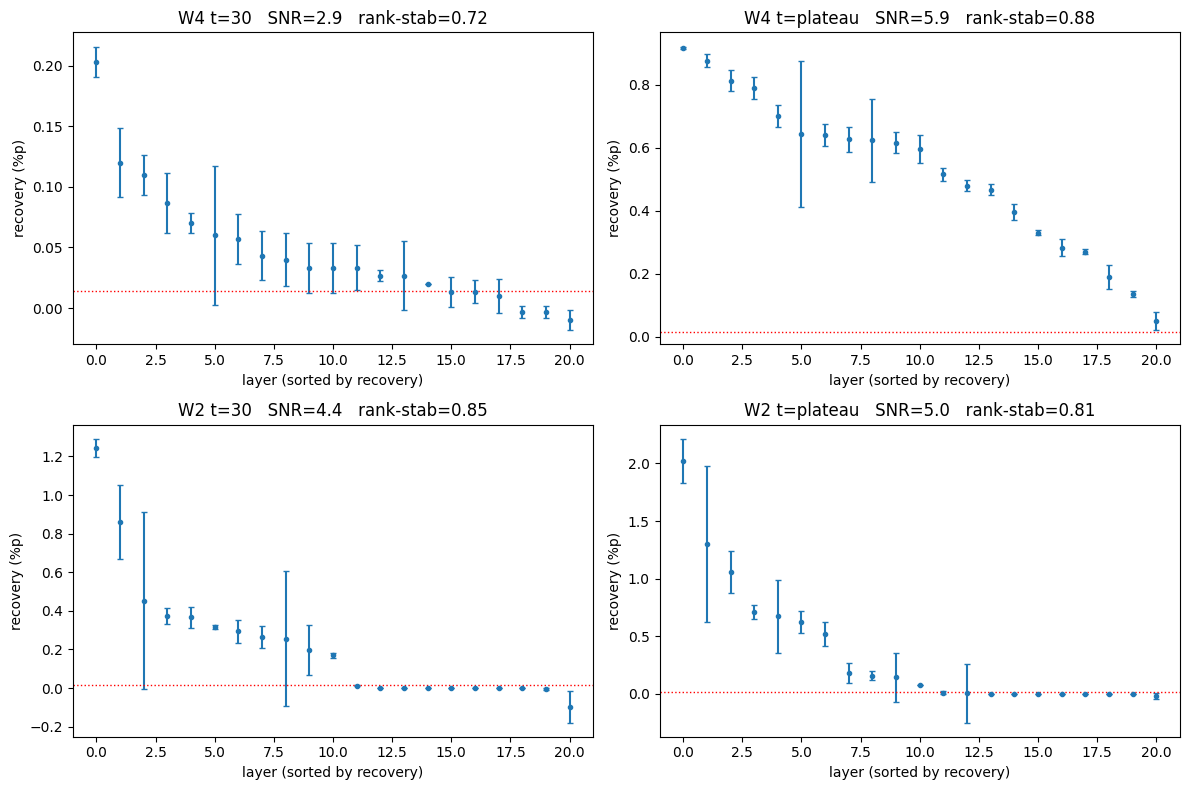

판정: 에러바가 서로 떨어지고 SNR>~3 & rank-stab>~0.5 여야 역전이 신호. 빨간점선=S0 노이즈


In [8]:
# FIG0 — 신호 검증 (★ 역전 믿기 전 필수): 층별 회복 mean±std(seed) + SNR/순위안정성
chk_bits = [b for b in BITS if RESULTS[b]['gap'] > 0.5]
fig, axs = plt.subplots(len(chk_bits), 2, figsize=(12, 4*len(chk_bits)), squeeze=False)
for r, bit in enumerate(chk_bits):
    for c, t in enumerate([30, 'plateau']):
        m = np.array(mean_R(bit, t)); sd = np.array(std_R(bit, t)); order = np.argsort(m)[::-1]
        ck = signal_check(bit, t); sn = ck['snr']; rs = ck['rank_stability']
        ax = axs[r][c]
        ax.errorbar(range(len(layers)), m[order], yerr=sd[order], fmt='o', ms=3, capsize=2)
        ax.axhline(NOISE_FLOOR, ls=':', color='red', lw=1)
        ax.set_xlabel('layer (sorted by recovery)'); ax.set_ylabel('recovery (%p)')
        ax.set_title(f'W{bit} t={t}   SNR={sn:.1f}   rank-stab={rs:.2f}')
plt.tight_layout(); plt.savefig(f'{FIG}/s1_signal_check.png', dpi=120); plt.show()
print('판정: 에러바가 서로 떨어지고 SNR>~3 & rank-stab>~0.5 여야 역전이 신호. 빨간점선=S0 노이즈')

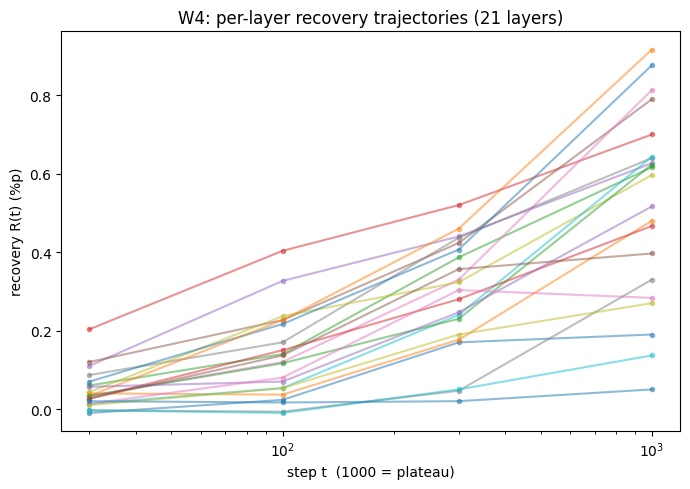

In [9]:
# FIG1 — W4 층별 회복 궤적
bit = 4
plt.figure(figsize=(7,5))
for L in layers:
    ys = [np.mean(RESULTS[bit]['R'][L][t]) for t in [30,100,300]] + [np.mean(RESULTS[bit]['R'][L]['plateau'])]
    plt.plot([30,100,300,1000], ys, alpha=0.5, marker='o', ms=3)
plt.xscale('log'); plt.xlabel('step t  (1000 = plateau)'); plt.ylabel('recovery R(t) (%p)')
plt.title(f'W{bit}: per-layer recovery trajectories ({len(layers)} layers)')
plt.tight_layout(); plt.savefig(f'{FIG}/s1_traj_w{bit}.png', dpi=120); plt.show()

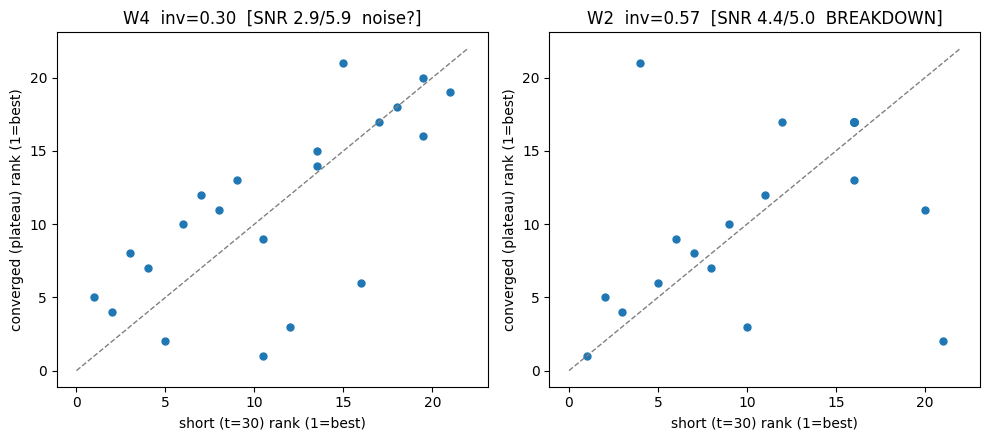

In [10]:
# FIG2 — 역전 산점도 (단기 vs 수렴 순위), 갭 있는 비트만. rank 1=best. 태그=summary와 동일 기준(t30+plateau)
from scipy.stats import rankdata
def best_rank(v):
    return len(v) + 1 - rankdata(v)
inv_bits = [b for b in BITS if RESULTS[b]['gap'] > 0.5]
fig, axs = plt.subplots(1, len(inv_bits), figsize=(5*len(inv_bits),4.5), squeeze=False)
for c, bit in enumerate(inv_bits):
    short = mean_R(bit, 30); plat = mean_R(bit, 'plateau')
    inv = inversion_strength(short, plat)
    c30 = signal_check(bit, 30); cpl = signal_check(bit, 'plateau')
    tag = 'BREAKDOWN' if is_breakdown(bit) else ('ok' if is_trustworthy(bit) else 'noise?')
    sn30 = c30['snr']; snpl = cpl['snr']
    ax = axs[0][c]; ax.scatter(best_rank(short), best_rank(plat), s=25)
    lim = [0, len(layers)+1]; ax.plot(lim, lim, '--', color='gray', lw=1)
    ax.set_xlabel('short (t=30) rank (1=best)'); ax.set_ylabel('converged (plateau) rank (1=best)')
    ax.set_title(f'W{bit}  inv={inv:.2f}  [SNR {sn30:.1f}/{snpl:.1f}  {tag}]')
plt.tight_layout(); plt.savefig(f'{FIG}/s1_inversion.png', dpi=120); plt.show()

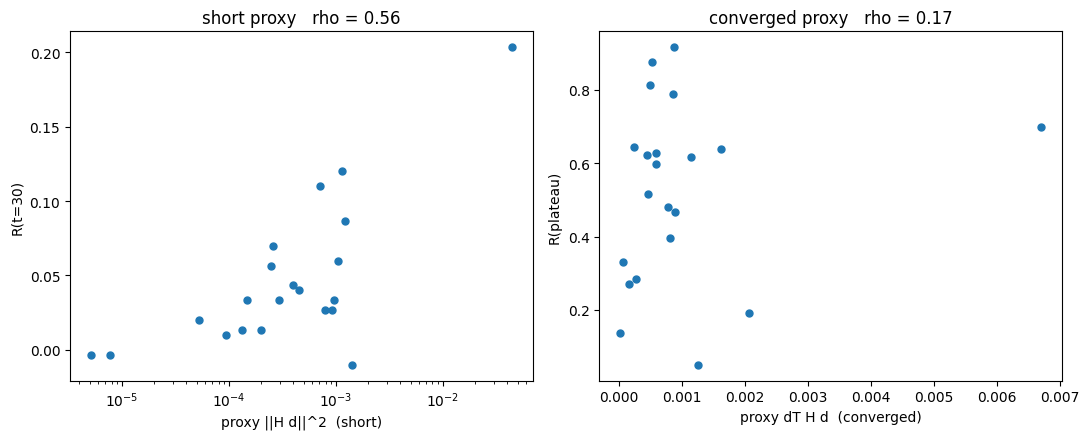

In [11]:
# FIG3 — proxy ↔ 회복 산점도 (W4): 단기 proxy vs R(30), 수렴 proxy vs R(plateau)
bit = 4
fig, axs = plt.subplots(1, 2, figsize=(11,4.5))
sh = mean_R(bit,30); nh = proxy_vec(bit,'normHd2')
axs[0].scatter(nh, sh, s=25); axs[0].set_xscale('log')
axs[0].set_xlabel('proxy ||H d||^2  (short)'); axs[0].set_ylabel('R(t=30)')
axs[0].set_title(f'short proxy   rho = {spearman(nh,sh):.2f}')
pl = mean_R(bit,'plateau'); dh = proxy_vec(bit,'dtHd')
axs[1].scatter(dh, pl, s=25)
axs[1].set_xlabel('proxy dT H d  (converged)'); axs[1].set_ylabel('R(plateau)')
axs[1].set_title(f'converged proxy   rho = {spearman(dh,pl):.2f}')
plt.tight_layout(); plt.savefig(f'{FIG}/s1_proxy_scatter_w{bit}.png', dpi=120); plt.show()

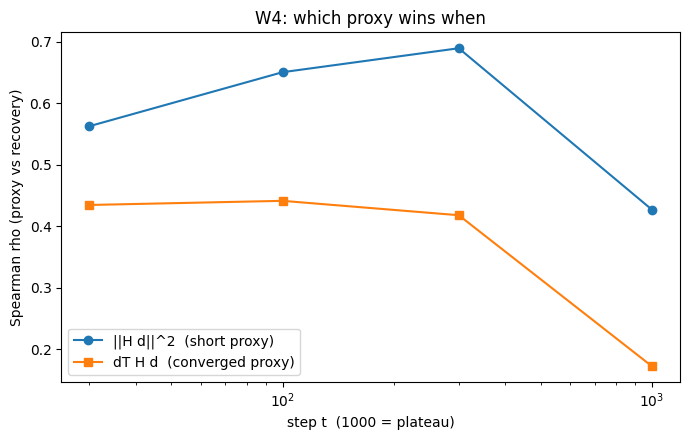

In [12]:
# FIG4 — rho vs t 교차 (W4): 어느 proxy가 언제 이기나 (||Hd||^2 단기, dT H d 수렴)
bit = 4
nh = proxy_vec(bit,'normHd2'); dh = proxy_vec(bit,'dtHd')
tk = [30,100,300,'plateau']; xs = [30,100,300,1000]
rho_short = [spearman(nh, mean_R(bit,t)) for t in tk]
rho_conv  = [spearman(dh, mean_R(bit,t)) for t in tk]
plt.figure(figsize=(7,4.5))
plt.plot(xs, rho_short, marker='o', label='||H d||^2  (short proxy)')
plt.plot(xs, rho_conv,  marker='s', label='dT H d  (converged proxy)')
plt.xscale('log'); plt.xlabel('step t  (1000 = plateau)'); plt.ylabel('Spearman rho (proxy vs recovery)')
plt.title(f'W{bit}: which proxy wins when'); plt.legend()
plt.tight_layout(); plt.savefig(f'{FIG}/s1_rho_vs_t_w{bit}.png', dpi=120); plt.show()

In [13]:
# RQ4 (전체) — 5종 proxy 다 vs R(t) 순위상관 (Spearman+Kendall), 비트별 표 + 저장
PROX_KEYS = ['normHd2','dtHd','fisher','werr','iso_out']
tk = [30,100,300,'plateau']
import csv as _csv2
for bit in [b for b in BITS if RESULTS[b]['gap'] > 0.5]:
    print(f'--- W{bit}: Spearman rho(proxy, R(t)) --- (각 t에서 |rho| 최대 proxy = best 예측자)')
    rows = []
    for key in PROX_KEYS:
        pv = proxy_vec(bit, key)
        rho_row = [spearman(pv, mean_R(bit, t)) for t in tk]
        tau_row = [kendall(pv, mean_R(bit, t)) for t in tk]
        disp = [round(x,3) if not np.isnan(x) else None for x in rho_row]
        rows.append([key] + disp + [round(x,3) if not np.isnan(x) else None for x in tau_row])
        print(f'  {key:9s} rho', disp)
    with open(f'{ART}/outputs/s1_proxy_rho_w{bit}.csv','w',newline='') as f:
        wr=_csv2.writer(f); wr.writerow(['proxy','rho30','rho100','rho300','rhoPlat','tau30','tau100','tau300','tauPlat']); wr.writerows(rows)
print('저장: s1_proxy_rho_w*.csv (5종 proxy 전부, Spearman+Kendall) — RQ4 완비')

--- W4: Spearman rho(proxy, R(t)) --- (각 t에서 |rho| 최대 proxy = best 예측자)
  normHd2   rho [0.563, 0.651, 0.69, 0.427]
  dtHd      rho [0.435, 0.442, 0.418, 0.173]
  fisher    rho [0.265, 0.534, 0.578, 0.352]
  werr      rho [-0.25, -0.088, -0.096, -0.23]
  iso_out   rho [0.474, 0.33, 0.31, 0.09]
--- W2: Spearman rho(proxy, R(t)) --- (각 t에서 |rho| 최대 proxy = best 예측자)
  normHd2   rho [0.302, 0.701, 0.822, 0.779]
  dtHd      rho [-0.374, -0.74, -0.822, -0.769]
  fisher    rho [0.191, 0.574, 0.738, 0.685]
  werr      rho [0.237, 0.635, 0.771, 0.717]
  iso_out   rho [0.009, 0.16, 0.152, 0.099]
저장: s1_proxy_rho_w*.csv (5종 proxy 전부, Spearman+Kendall) — RQ4 완비


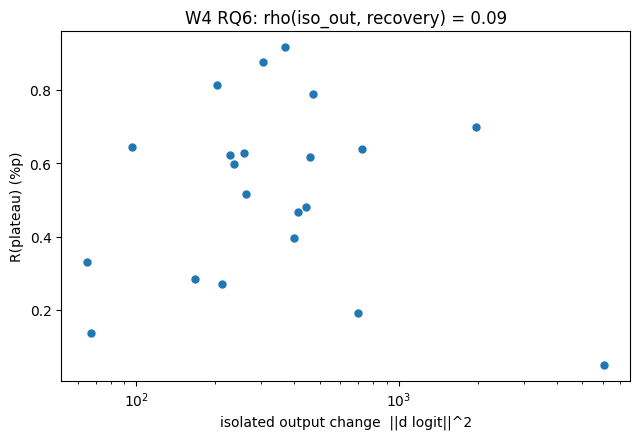

RQ6: rho = 0.090  ->  POS (refutes)


In [14]:
# RQ6 — 반직관: isolated output 변화 vs 실제 회복 상관 (음수면 출력변화 작은 층이 더 회복)
bit = 4
io = proxy_vec(bit, 'iso_out'); rp = mean_R(bit, 'plateau')
rho_io = spearman(io, rp)
tag = 'NEG: small-output-change layers recover MORE (reproduces)' if rho_io < 0 else 'POS (refutes)'
plt.figure(figsize=(6.5,4.5))
plt.scatter(io, rp, s=25); plt.xscale('log')
plt.xlabel('isolated output change  ||d logit||^2'); plt.ylabel('R(plateau) (%p)')
plt.title(f'W{bit} RQ6: rho(iso_out, recovery) = {rho_io:.2f}')
plt.tight_layout(); plt.savefig(f'{FIG}/s1_rq6_isoout_w{bit}.png', dpi=120); plt.show()
print(f'RQ6: rho = {rho_io:.3f}  ->  {tag}')

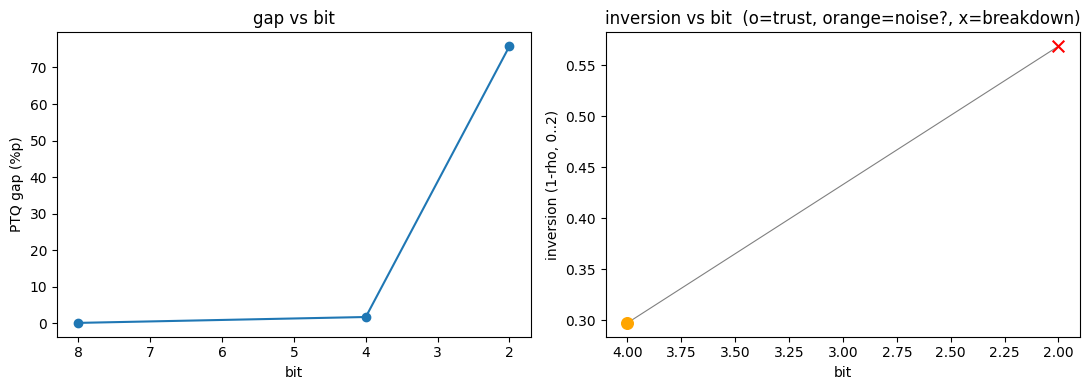

그림 전체 저장 → /content/drive/MyDrive/26_Capstone/figures


In [15]:
# FIG5 — 갭 vs 비트 (전체) + 역전강도 vs 비트 (trust/noise/breakdown 색구분, summary와 동일 기준)
bs = list(BITS); gaps = [RESULTS[b]['gap'] for b in bs]
inv_bits = [b for b in bs if RESULTS[b]['gap'] > 0.5]
invs = [inversion_strength(mean_R(b,30), mean_R(b,'plateau')) for b in inv_bits]
fig, axs = plt.subplots(1, 2, figsize=(11,4))
axs[0].plot(bs, gaps, marker='o'); axs[0].set_xlabel('bit'); axs[0].set_ylabel('PTQ gap (%p)'); axs[0].set_title('gap vs bit'); axs[0].invert_xaxis()
axs[1].plot(inv_bits, invs, color='gray', lw=0.8, zorder=0)
for b, iv in zip(inv_bits, invs):
    bd = is_breakdown(b); trust = is_trustworthy(b)
    col = 'red' if bd else ('C0' if trust else 'orange'); mk = 'x' if bd else 'o'
    axs[1].scatter([b], [iv], color=col, marker=mk, s=70)
axs[1].set_xlabel('bit'); axs[1].set_ylabel('inversion (1-rho, 0..2)'); axs[1].set_title('inversion vs bit  (o=trust, orange=noise?, x=breakdown)'); axs[1].invert_xaxis()
plt.tight_layout(); plt.savefig(f'{FIG}/s1_vs_bit.png', dpi=120); plt.show()
print('그림 전체 저장 →', FIG)

In [16]:
# 요약 저장 — summary.json + csv + 신호검증 표
import json as _json, csv as _csv
def _safe(v):
    return None if (v is None or (isinstance(v, float) and np.isnan(v))) else round(float(v), 4)
summary = {'fp_acc': fp_acc, 'bits': {}}
for bit in RESULTS:
    g = RESULTS[bit]['gap']
    c30 = signal_check(bit, 30); cpl = signal_check(bit, 'plateau')
    inv = inversion_strength(mean_R(bit,30), mean_R(bit,'plateau')) if g > 0.5 else None
    summary['bits'][str(bit)] = dict(
        gap=round(g,3), ptq_acc=round(RESULTS[bit]['ptq_acc'],2),
        mean_recovery_plateau=round(cpl['mean_recovery'],3),
        spread_t30=_safe(c30['spread']), spread_plateau=_safe(cpl['spread']),
        seed_noise_t30=_safe(c30['seed_noise']), seed_noise_plateau=_safe(cpl['seed_noise']),
        snr_t30=_safe(c30['snr']), snr_plateau=_safe(cpl['snr']),
        rank_stability_t30=_safe(c30['rank_stability']), rank_stability_plateau=_safe(cpl['rank_stability']),
        breakdown=bool(is_breakdown(bit)),
        inversion_strength=_safe(inv),
        inversion_trustworthy=bool(is_trustworthy(bit)),
        rho_short_R30=_safe(spearman(proxy_vec(bit,'normHd2'), mean_R(bit,30))),
        rho_conv_Rplateau=_safe(spearman(proxy_vec(bit,'dtHd'), mean_R(bit,'plateau'))),
    )
    s30 = std_R(bit,30); spl = std_R(bit,'plateau')
    with open(f'{ART}/outputs/s1_recovery_mean_w{bit}.csv', 'w', newline='') as f:
        w = _csv.writer(f); w.writerow(['layer','R30','R100','R300','Rplateau','std30','stdPlateau'])
        for i, L in enumerate(layers):
            w.writerow([L] + [round(np.mean(RESULTS[bit]['R'][L][t]),4) for t in [30,100,300,'plateau']] + [round(s30[i],4), round(spl[i],4)])
_json.dump(summary, open(f'{ART}/outputs/s1_summary.json','w'), indent=2, ensure_ascii=False)
print('저장: s1_summary.json + csv')
for b in summary['bits']:
    s = summary['bits'][b]
    print('W'+b, '| gap', s['gap'], '| snr30', s['snr_t30'], '| snrPl', s['snr_plateau'], '| inv', s['inversion_strength'], '| TRUST', s['inversion_trustworthy'], '| breakdown', s['breakdown'])

저장: s1_summary.json + csv
W8 | gap 0.06 | snr30 1.3358 | snrPl 1.9883 | inv None | TRUST False | breakdown False
W4 | gap 1.67 | snr30 2.8768 | snrPl 5.9455 | inv 0.2974 | TRUST False | breakdown False
W2 | gap 75.84 | snr30 4.4281 | snrPl 4.9578 | inv 0.5687 | TRUST False | breakdown True


## S1 완료 — 무엇을 볼까 (★ 신호 검증 먼저)

**0. FIG0 신호 검증 (가장 먼저):** 층별 회복 에러바가 *떨어져* 있고 **SNR>~3 & rank-stab>~0.5** 여야 순위가 진짜. 깨지면 **역전 숫자 무의미**(noise가 inv≈1로 위장). `summary.json`의 `inversion_trustworthy=False`면 그 비트 역전 믿지 말 것.

1. **역전 (RQ2, FIG2):** 제목 `[SNR t30/plateau · ok·noise?·BREAKDOWN]` (summary와 동일 기준). ok인 비트만 — 대각선 벗어남 = 단기 best ≠ 수렴 best.
2. **proxy 예측 (RQ4):** FIG3·FIG4(HVP 2종 교차) + RQ4 표(`s1_proxy_rho_*.csv`, 5종 proxy 전부 ρ·τ) — 각 t에서 어느 proxy가 이기나.
3. **반직관 (RQ6):** iso_out↔회복 상관 — 음수면 출력변화 작은 층이 더 회복(재현), 양수면 반박.
4. **비트 의존 (RQ3, FIG5):** 비트 낮을수록 역전 커지나. **W2 breakdown=True면 그건 붕괴지 역전 아님.**

**아직 안 한 것 (정직):** RQ3의 §4.2 닫힌형태 *곡선* 적합도 → breakdown bit는 미구현(층별 λ 스펙트럼 fit 필요 = 천장). 현재 RQ3 = 역전vs비트 + 붕괴플래그 + proxy교차(FIG4 = λ²vsλ 부분검증). 닫힌형태 fit은 결과 보고 추가/순연.

→ 결과(`summary.json` + `s1_proxy_rho_*.csv` + 그림들) 갖고 와서 같이 해석.